# Quran Qari (Reciter) Classifier

**Goal.** Given a short audio clip of Quran recitation, predict which qari (reciter) is reading. Shazam-style — user uploads audio, model returns top matches with confidence.

**Dataset.** Assembled from three sources into a single unified format:
- 12 Arab qaris from Kaggle `mohammedalrajeh/quran-recitations-for-audio-classification` (pre-segmented WAV)
- 15 extra Arab qaris scraped from everyayah.com (Juz 30 sample per qari)
- 3–5 Uzbek qaris (added manually via `data/raw_uzbek/` — YouTube blocks yt-dlp without cookies)

All audio unified: 5-second clips, mono, 16 kHz, peak-normalized. Features: MFCC + delta + delta-delta + spectral stats.

**Pipeline.**
1. Setup
2. Load features + labels
3. EDA (class balance, feature distributions, PCA)
4. Train / test split (stratified)
5. Baseline — Logistic Regression
6. Bake-off (LogReg, KNN, RF, XGBoost)
7. Hyper-parameter tuning
8. Final evaluation (per-class report, confusion matrix, top-3 accuracy)
9. Feature importance
10. Save artifacts for deployment
11. Streamlit deployment notes

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    top_k_accuracy_score, ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
DATA_DIR = Path('data')

## 2. Load features & labels

Features + labels are produced by `scripts/segment_and_features.py`. Run that first if `data/features.parquet` is missing.

In [2]:
features_path = DATA_DIR / 'features.parquet'
labels_path   = DATA_DIR / 'labels.csv'

assert features_path.exists(), f'{features_path} missing — run scripts/segment_and_features.py first'
assert labels_path.exists(),   f'{labels_path} missing — run scripts/segment_and_features.py first'

feat_df  = pd.read_parquet(features_path)
label_df = pd.read_csv(labels_path)
df = feat_df.merge(label_df, on='clip')
print('Shape:', df.shape)
print('Reciters:', df['reciter'].nunique())
df.head()

Shape: (13688, 128)
Reciters: 25


,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,...,delta2_18_std,delta2_19_std,zcr_mean,zcr_std,centroid_mean,centroid_std,rolloff_mean,rolloff_std,clip,reciter
0,-319.550262,51.869236,-10.971118,18.388348,7.500530,3.905689,-10.550270,2.714843,3.261332,1.336559,...,0.599903,0.490284,0.054280,0.062165,745.771535,757.985251,1394.108280,1428.108382,00000_d9904cf267af.wav,AbdulBari_Althubaity
1,-301.067810,46.342281,-10.076772,16.317682,-0.364362,5.812458,-11.144876,1.354251,1.575410,0.879092,...,0.481136,0.401256,0.070269,0.079066,922.634482,977.918024,1780.105494,1860.150070,00001_8da680302020.wav,AbdulBari_Althubaity
2,-301.692017,46.994419,-13.349220,12.797167,-0.666370,6.009683,-11.791127,5.309660,-1.270388,1.428817,...,0.396712,0.455113,0.066537,0.071863,884.038585,889.328819,1747.163615,1762.021600,00002_71be07d67c33.wav,AbdulBari_Althubaity
3,-296.047607,54.269524,-11.925815,16.783207,4.651449,1.956431,-4.339514,7.173192,0.619890,2.343131,...,0.496061,0.453289,0.050321,0.053025,757.384090,751.458375,1455.463774,1454.150484,00003_46eddcd89f55.wav,AbdulBari_Althubaity
4,-324.239990,42.486320,-19.104933,13.954841,9.672489,3.225590,-11.174574,1.474234,7.834001,3.116694,...,0.397615,0.394772,0.078396,0.083767,898.461774,890.056120,1617.983678,1610.631144,00004_5efdf74d8e2a.wav,AbdulBari_Althubaity


## 3. Exploratory Data Analysis

### 3.1 Class distribution — clips per qari

reciter
Yasser_Aldossary        400
Abdullah_Albuaijan      400
Ali_Alhothaify          400
Bander_Balilah          400
Maher_Almuaiqly         400
AbdulBari_Althubaity    400
Mohammed_Ayoub          400
Nasser_Alqutami         400
Saad_Alghamdi           400
Mohammed_Aluhaidan      400
Saud_Alshuraim          400
AbdulRahman_Alsudais    400
Abdullah_Al_Juhany      436
Muhsin_Al_Qasim         455
Husary                  539
Fares_Abbad             558
Muhammad_Jibreel        590
Minshawy                688
Khalid_Al_Qahtani       697
Salah_Bukhatir          725
Salah_Al_Budair         781
Hani_Rifai              785
Mishary_Alafasy         817
Abu_Bakr_Shatri         885
Abdul_Basit             932
Name: count, dtype: int64

Total clips: 13688
Min per class: 400  |  Max per class: 932  |  Median: 436


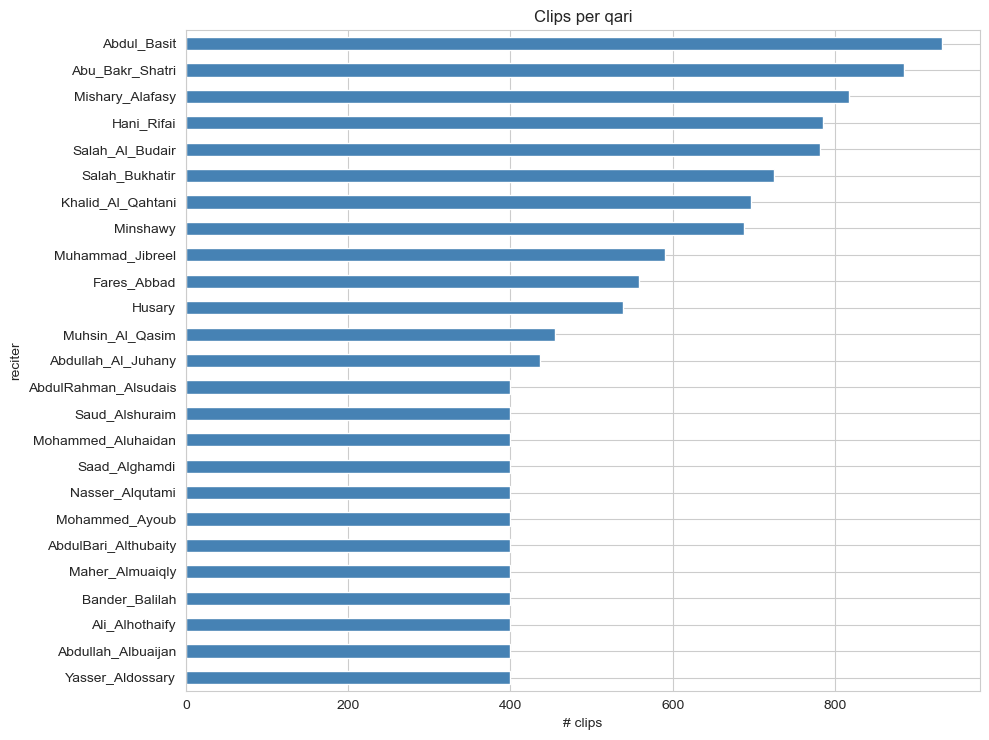

In [3]:
vc = df['reciter'].value_counts().sort_values(ascending=True)
print(vc)
print(f'\nTotal clips: {len(df)}')
print(f'Min per class: {vc.min()}  |  Max per class: {vc.max()}  |  Median: {int(vc.median())}')

plt.figure(figsize=(10, max(4, len(vc) * 0.3)))
vc.plot(kind='barh', color='steelblue')
plt.title('Clips per qari')
plt.xlabel('# clips')
plt.tight_layout()
plt.show()

### 3.2 Feature space overview

Quick check: how many features per clip, what are their scales?

In [4]:
feature_cols = [c for c in df.columns if c not in ('clip', 'reciter')]
print(f'Features per clip: {len(feature_cols)}')
print(df[feature_cols].describe().T[['mean', 'std', 'min', 'max']].round(2).head(10))

Features per clip: 126


               mean    std     min     max
mfcc_0_mean -228.27  84.91 -497.59  -31.75
mfcc_1_mean   58.12  23.94  -13.63  138.66
mfcc_2_mean  -27.61  20.48 -100.49   30.42
mfcc_3_mean   15.88  14.67  -64.55   82.93
mfcc_4_mean  -17.92  13.63  -71.00   38.13
mfcc_5_mean   -6.42  10.04  -42.70   24.09
mfcc_6_mean   -8.69  10.35  -51.06   24.26
mfcc_7_mean  -17.60  12.70  -52.49   31.71
mfcc_8_mean   -2.97   7.45  -28.20   33.32
mfcc_9_mean   -2.22   7.74  -39.58   28.53


### 3.3 PCA — 2D projection colored by qari

If qaris cluster visibly in 2D, classifier will thrive. If they overlap heavily, need richer features (CNN on spectrograms).

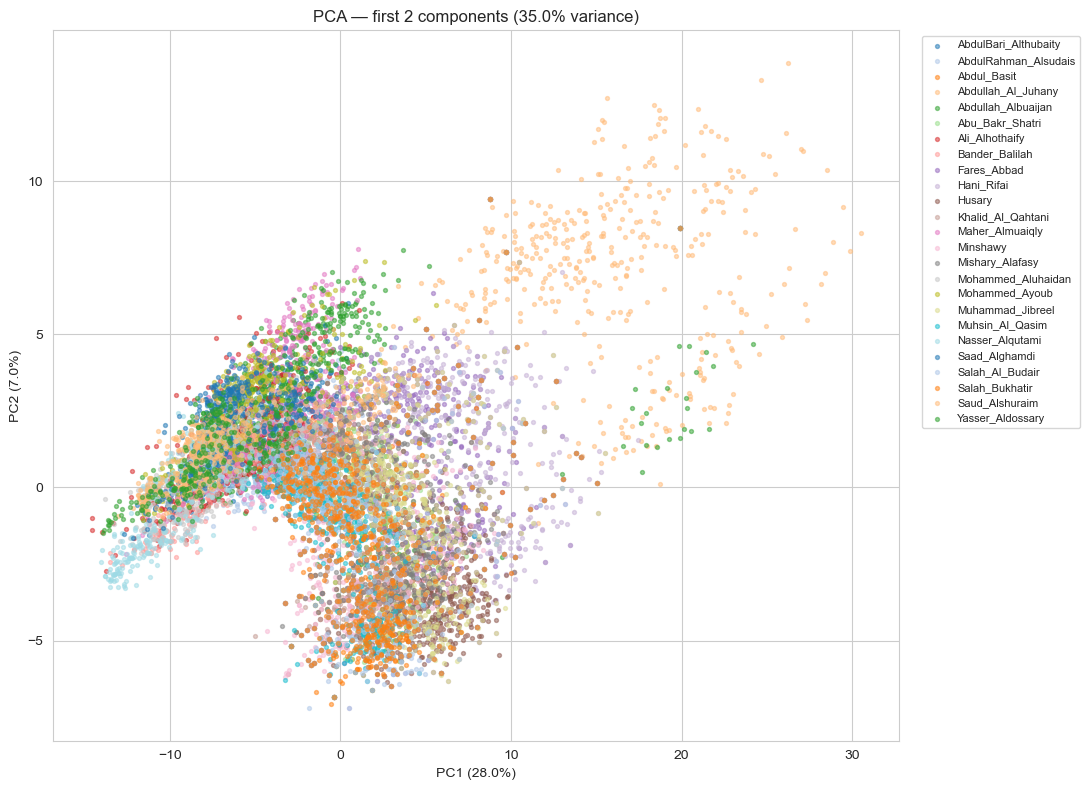

In [5]:
scaler_diag = StandardScaler()
X_diag = scaler_diag.fit_transform(df[feature_cols])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_diag)

plt.figure(figsize=(11, 8))
reciters = sorted(df['reciter'].unique())
palette = sns.color_palette('tab20', len(reciters))
for r, color in zip(reciters, palette):
    mask = df['reciter'].values == r
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, color=color, label=r)
plt.title(f'PCA — first 2 components ({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Feature preparation & stratified split

In [6]:
X = df[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(df['reciter'])
print('Classes:', list(le.classes_))
print('X:', X.shape, '| y:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Classes: ['AbdulBari_Althubaity', 'AbdulRahman_Alsudais', 'Abdul_Basit', 'Abdullah_Al_Juhany', 'Abdullah_Albuaijan', 'Abu_Bakr_Shatri', 'Ali_Alhothaify', 'Bander_Balilah', 'Fares_Abbad', 'Hani_Rifai', 'Husary', 'Khalid_Al_Qahtani', 'Maher_Almuaiqly', 'Minshawy', 'Mishary_Alafasy', 'Mohammed_Aluhaidan', 'Mohammed_Ayoub', 'Muhammad_Jibreel', 'Muhsin_Al_Qasim', 'Nasser_Alqutami', 'Saad_Alghamdi', 'Salah_Al_Budair', 'Salah_Bukhatir', 'Saud_Alshuraim', 'Yasser_Aldossary']
X: (13688, 126) | y: (13688,)
Train: (10950, 126) | Test: (2738, 126)


## 5. Baseline — Logistic Regression

In [7]:
baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1)
baseline.fit(X_train_s, y_train)
pred  = baseline.predict(X_test_s)
proba = baseline.predict_proba(X_test_s)

print(f'Accuracy       : {accuracy_score(y_test, pred):.4f}')
print(f'Top-3 accuracy : {top_k_accuracy_score(y_test, proba, k=3):.4f}')
print(f'\nClassification report:')
print(classification_report(y_test, pred, target_names=le.classes_))

Accuracy       : 0.6841
Top-3 accuracy : 0.8163

Classification report:
                      precision    recall  f1-score   support

AbdulBari_Althubaity       0.92      0.91      0.92        80
AbdulRahman_Alsudais       0.96      0.96      0.96        80
         Abdul_Basit       0.37      0.40      0.38       187
  Abdullah_Al_Juhany       0.88      0.86      0.87        87
  Abdullah_Albuaijan       0.94      0.96      0.95        80
     Abu_Bakr_Shatri       0.34      0.34      0.34       177
      Ali_Alhothaify       0.95      0.90      0.92        80
      Bander_Balilah       0.86      0.93      0.89        80
         Fares_Abbad       0.62      0.69      0.65       112
          Hani_Rifai       0.43      0.46      0.45       157
              Husary       0.73      0.78      0.75       108
   Khalid_Al_Qahtani       0.51      0.49      0.50       139
     Maher_Almuaiqly       0.98      1.00      0.99        80
            Minshawy       0.59      0.57      0.58       1

## 6. Model bake-off — defaults

Same split, uniform metrics. Track accuracy, top-3, macro-F1.

             model  accuracy   top3  macro_f1
LogisticRegression    0.6841 0.8163    0.7537
               KNN    0.6406 0.7337    0.7464
      RandomForest    0.6286 0.7772    0.7221
           XGBoost    0.6242 0.7739    0.7185


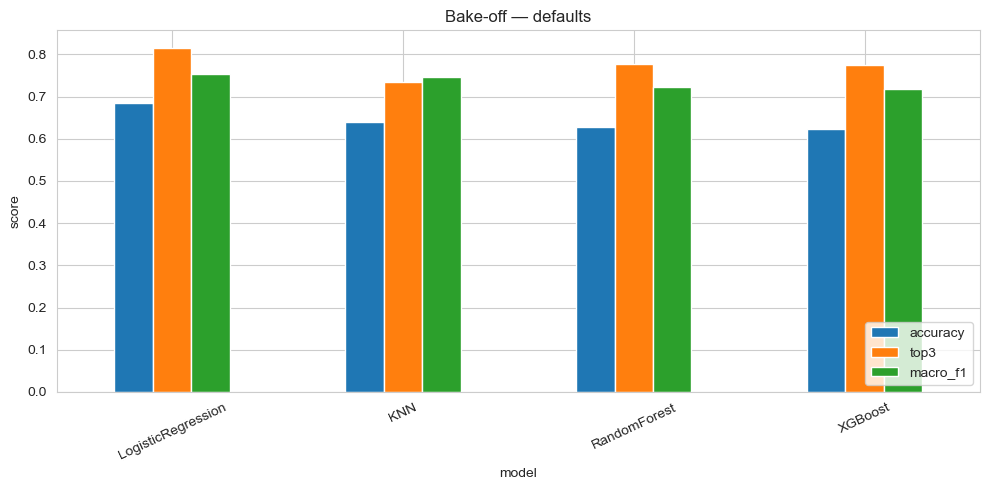

In [8]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'RandomForest':       RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=400, learning_rate=0.1, max_depth=5,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1,
    )

rows = []
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    pred  = mdl.predict(X_test_s)
    proba = mdl.predict_proba(X_test_s)
    rep   = classification_report(y_test, pred, output_dict=True, zero_division=0)
    rows.append({
        'model':    name,
        'accuracy': accuracy_score(y_test, pred),
        'top3':     top_k_accuracy_score(y_test, proba, k=3),
        'macro_f1': rep['macro avg']['f1-score'],
    })

results_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
print(results_df.round(4).to_string(index=False))

results_df.set_index('model')[['accuracy', 'top3', 'macro_f1']].plot(kind='bar', figsize=(10, 5))
plt.title('Bake-off — defaults')
plt.ylabel('score')
plt.xticks(rotation=25)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Hyper-parameter tuning — top model

Tune the leader by macro-F1 with 5-fold CV. Others typically don't catch up on tabular MFCC — tuning is a spot-check, not a horse race.

In [9]:
top_name = results_df.iloc[0]['model']
print(f'Tuning: {top_name}')

if top_name == 'RandomForest':
    est = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    grid = {'n_estimators': [300, 600], 'max_depth': [None, 20, 40], 'min_samples_split': [2, 5]}
elif top_name == 'XGBoost' and HAS_XGB:
    est = XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
    grid = {'n_estimators': [300, 600], 'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1]}
elif top_name == 'LogisticRegression':
    est = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1)
    grid = {'C': [0.1, 1, 10], 'penalty': ['l2']}
elif top_name == 'KNN':
    est = KNeighborsClassifier(n_jobs=-1)
    grid = {'n_neighbors': [3, 5, 11, 21], 'weights': ['uniform', 'distance']}

gs = GridSearchCV(est, grid, scoring='f1_macro', cv=5, n_jobs=-1, verbose=1)
gs.fit(X_train_s, y_train)
print(f'best CV macro-F1 : {gs.best_score_:.4f}')
print(f'best params      : {gs.best_params_}')
best_model = gs.best_estimator_

Tuning: LogisticRegression
Fitting 5 folds for each of 3 candidates, totalling 15 fits


best CV macro-F1 : 0.7484
best params      : {'C': 0.1, 'penalty': 'l2'}


## 8. Final evaluation

In [10]:
pred  = best_model.predict(X_test_s)
proba = best_model.predict_proba(X_test_s)

print(f'Accuracy       : {accuracy_score(y_test, pred):.4f}')
print(f'Top-3 accuracy : {top_k_accuracy_score(y_test, proba, k=3):.4f}')
print(f'\nClassification report:')
print(classification_report(y_test, pred, target_names=le.classes_))

Accuracy       : 0.6892
Top-3 accuracy : 0.8210

Classification report:
                      precision    recall  f1-score   support

AbdulBari_Althubaity       0.93      0.94      0.93        80
AbdulRahman_Alsudais       0.93      0.97      0.95        80
         Abdul_Basit       0.37      0.41      0.38       187
  Abdullah_Al_Juhany       0.89      0.91      0.90        87
  Abdullah_Albuaijan       0.94      0.96      0.95        80
     Abu_Bakr_Shatri       0.35      0.37      0.36       177
      Ali_Alhothaify       0.96      0.90      0.93        80
      Bander_Balilah       0.85      0.89      0.87        80
         Fares_Abbad       0.65      0.72      0.68       112
          Hani_Rifai       0.46      0.47      0.46       157
              Husary       0.75      0.79      0.77       108
   Khalid_Al_Qahtani       0.53      0.48      0.51       139
     Maher_Almuaiqly       0.99      0.99      0.99        80
            Minshawy       0.57      0.57      0.57       1

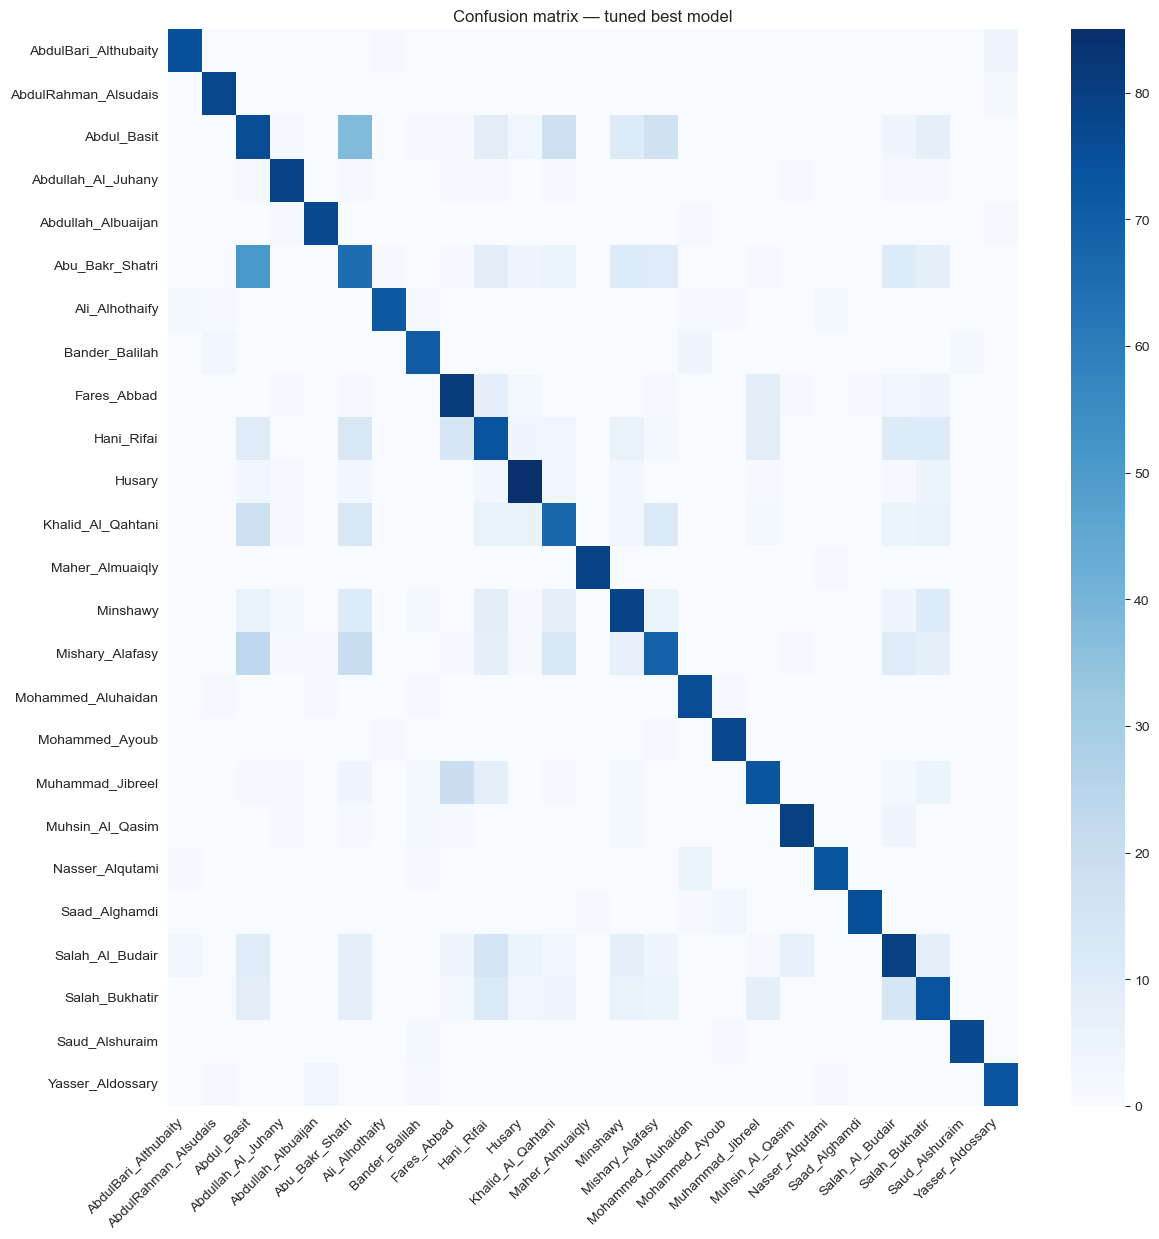

In [11]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(max(8, len(le.classes_) * 0.5), max(6, len(le.classes_) * 0.5)))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Confusion matrix — tuned best model')
plt.tight_layout()
plt.show()

## 9. Feature importance

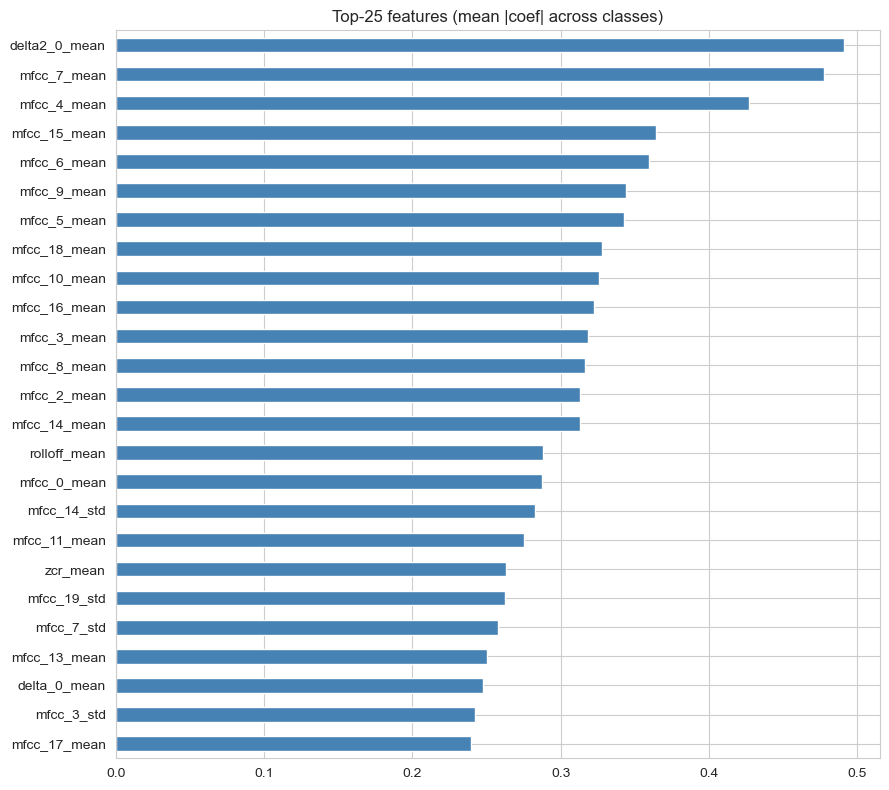

In [12]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(25)
    imp[::-1].plot(kind='barh', figsize=(9, 8), color='steelblue')
    plt.title('Top-25 features')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    imp = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=feature_cols).sort_values(ascending=False).head(25)
    imp[::-1].plot(kind='barh', figsize=(9, 8), color='steelblue')
    plt.title('Top-25 features (mean |coef| across classes)')
    plt.tight_layout()
    plt.show()
else:
    print(f'{type(best_model).__name__} has no direct feature-importance attribute.')

## 10. Save artifacts for deployment

In [13]:
artifacts = {
    'model':         best_model,
    'scaler':        scaler,
    'label_encoder': le,
    'feature_cols':  feature_cols,
    'sr':            16000,
    'clip_sec':      5,
    'model_name':    type(best_model).__name__,
}
joblib.dump(artifacts, 'qari_artifacts.joblib')
print('Saved: qari_artifacts.joblib')

Saved: qari_artifacts.joblib


## 11. Streamlit deployment

See `app.py` — Shazam-style upload:
1. User uploads an audio file (mp3 / wav / m4a).
2. App loads, converts to 16 kHz mono, segments into 5s clips.
3. Extracts MFCC + delta + spectral features per clip using the same pipeline.
4. Averages per-clip probabilities.
5. Displays top-3 predicted qaris with confidence bars + waveform + mel spectrogram.

**Run locally:**
```bash
streamlit run app.py
```

**Deploy to Streamlit Cloud:**
1. Push `app.py`, `qari_artifacts.joblib`, `requirements.txt` to a GitHub repo.
2. Go to https://share.streamlit.io → New app → pick repo → Deploy.
3. Public URL is permanent.